# Data exploration: visualization + data science

Data exploration is essential to explaining trends in data-driven materials science.
Handling data, however, is not a simple task.
In this notebook, we will demonstrate how to use visualizations and data science to answer questions related to materials science data.

In this notebook, we will use the perovskite dataset from the following publications:

- A. Emery and C. Wolverton. *Sci. Data.* **4**, 170153 (2017). [[link]](https://www.nature.com/articles/sdata2017153) [[FigShare]](https://doi.org/10.6084/m9.figshare.5334142)
- A. Emery et al. *Chem. Mater.* **28**, 5621 (2016). [[paper]](https://pubs.acs.org/doi/pdf/10.1021/acs.chemmater.6b01182)

As a reminder, a perovskite is an inorganic crystal structure that has the structure similar to BaTiO$_3$, and is often represented with the ABX$_3$ stoichiometry:

![image.png](pvsk.png)

*(Figure from Callister and Rethwisch, 10th ed.)*

The techniques from the previous lecture, in addition to some of the things we discussed in this lecture, will be used to create insights on design principles related to perovskite oxides.

## Setting up the Environment

Before starting the analysis, we begin by setting up our Python environment with the necessary libraries for data manipulation and visualization. We import libraries such as `numpy`, `pandas`, `seaborn`, and `matplotlib`. We also configure the plotting style to ensure clear, high-resolution figures suitable for academic purposes. Finally, we load the periodic table from the previous lecture to make some analysis easier for our purposes:

In [1]:
try:
    import google.colab
    IN_COLAB = True
    !git clone https://github.com/dskoda/ml4mat-26s-public.git
    !cd ml4mat-26s-public && pip install . && cd ..
    ROOT = "https://raw.githubusercontent.com/dskoda/ml4mat-26s-public/refs/heads/main/lectures"
    STYLE = "colab"
except:
    IN_COLAB = False
    ROOT = ".."
    STYLE = "jupyter"

In [2]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats

import ml4mat_ucla as m4m

plt.style.use(STYLE)
m4m.utils.set_dpi(200)

## Loading and Preparing the Data

Next, we load the periodic table information to reference elemental properties and prepare our main dataset containing perovskite compounds. We rename the columns for clarity and drop unnecessary columns to focus on properties like chemical formula, stability, and electronic characteristics.

In [3]:
# Load elemental data
pt = pd.read_csv(f"{ROOT}/01-DataScience/data/ptable.csv").set_index("Symbol")

# Define new column names and columns to drop
# This makes it easier to write code and perform data exploration
renamer = {
    'Chemical formula': "formula",
    'In literature': "known",
    'Valence A': "vA",
    'Valence B': "vB",
    'Radius A [ang]': "rA",
    'Radius B [ang]': "rB",
    'Lowest distortion': "lattice",
    'Formation energy [eV/atom]': "Hf",
    'Stability [eV/atom]': "stability",
    'Magnetic moment [mu_B]': "muB",
    'Volume per atom [A^3/atom]': "vol",
    'Band gap [eV]': "gap",
    'Vacancy energy [eV/O atom]': "Ev",
}

to_drop = [
    'a [ang]',
    'b [ang]',
    'c [ang]',
    'alpha [deg]',
    'beta [deg]',
    'gamma [deg]',
]

# Load, clean, and rename perovskite data
df = (
    pd.read_csv(f"{ROOT}/02-Datasets/data/perovskites.csv")
    .drop(to_drop, axis=1)
    .rename(columns=renamer)
)

Another important step is to clean the data.
As it comes, it creates some problems in the data visualization.
In particular, the absent data should be treated as a `NaN`, not as a dash, `-`.
We perform this step of data cleaning after analyzing the data manually and verifying the authors' choices on doing this.

In [4]:
df.loc[:, "Ev"] = [float(x) if x != "-" else float("NaN") for x in df["Ev"]]
df.loc[:, "Hf"] = [float(x) if x != "-" else float("NaN") for x in df["Hf"]]

## Analyzing Chemical and Physical Properties

We calculate additional properties such as the difference in ionic radii (`dR`) and valence (`dV`) between elements A and B in the ABX$_3$ structure. These differences often relate to structural distortions and stability, which are critical in predicting essential structure-property relationships.

In [5]:
not_allowed = ['element not in BV', 'not balanced']

df["dR"] = df["rA"] - df["rB"]

df.loc[:, "vA"] = [float(x) if x not in not_allowed else float("NaN") for x in df["vA"]]
df.loc[:, "vB"] = [float(x) if x not in not_allowed else float("NaN") for x in df["vB"]]
df.loc[:, "dV"] = df["vA"] - df["vB"]

## Adding features to the space of perovskites

Now, instead of relying solely on the data that was provided to us, we can start adding new features to it.
Let's add, for example, the information from the periodic table to our dataset

In [6]:
df["EnegA"] = pt.loc[df["A"], "Electronegativity"].values
df["EnegB"] = pt.loc[df["B"], "Electronegativity"].values
df["dEneg"] = df["EnegA"] - df["EnegB"]

df["gA"] = pt.loc[df["A"], "Group"].values
df["gB"] = pt.loc[df["B"], "Group"].values
df["pA"] = pt.loc[df["A"], "Period"].values
df["pB"] = pt.loc[df["B"], "Period"].values

Finally, we can create subsets of the initial DataFrame to explore correlations in a reasonable set of structures:

In [7]:
subdf = df.loc[(~df["vA"].isna()) & (~df["vB"].isna())].copy()

## Generating hypotheses in the perovskite space

Now that the data is clean, we can start generating hypotheses in the perovskite space.
These hypotheses are useful for us to extract insights from the data and start designing materials or producing materials science knowledge from data.
Let us see how to use the knowledge from the previous lecture to do so.

### Correlations between Structure and perovskite stability

We visualize how elemental properties of perovskites dictate stability of these materials.
First, let's see if radii influence the computed stability:

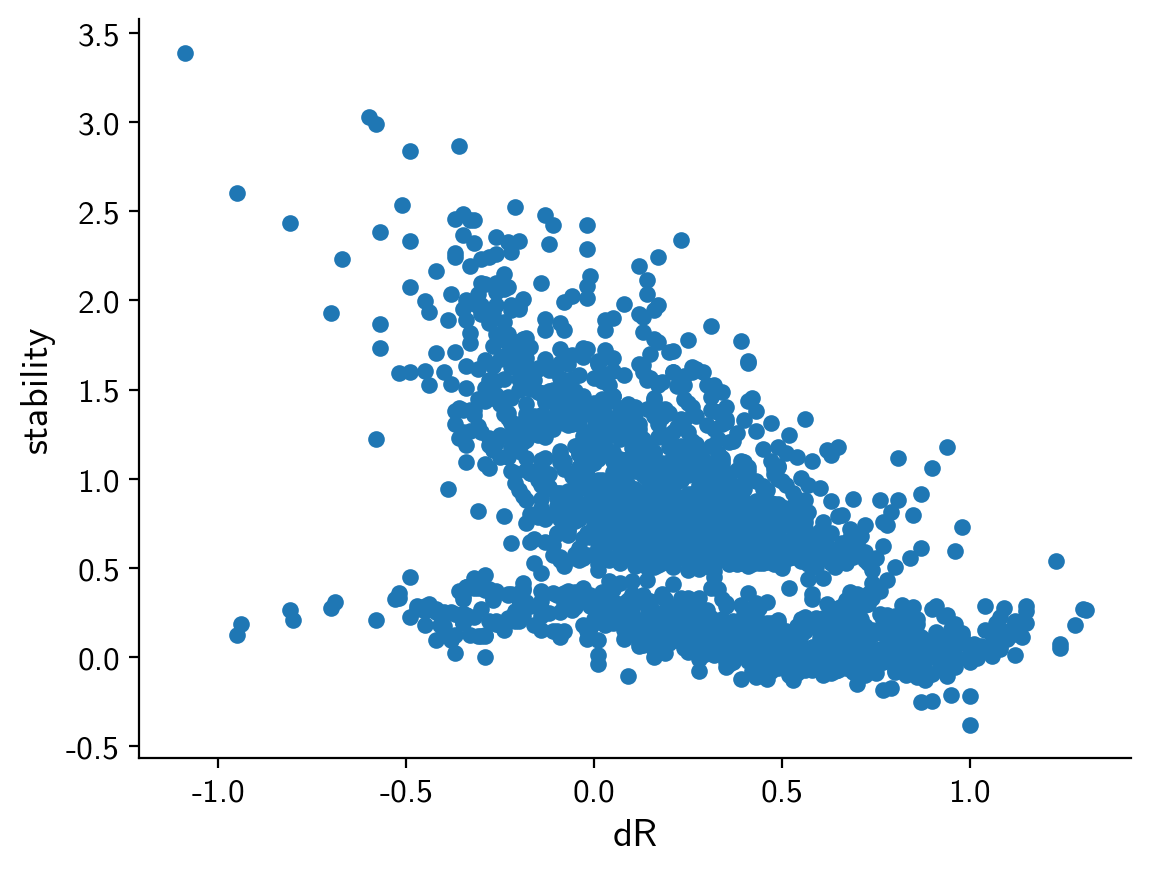

In [8]:
fig, ax = plt.subplots()

sns.scatterplot(
    data=subdf,
    x="dR",
    y="stability",
    linewidth=0,
)

plt.show()

Looks like they do! But there seems to be two regimes in the plot above.
Can we try to explain the results a bit more, perhaps to see if they belong to different lattice types?

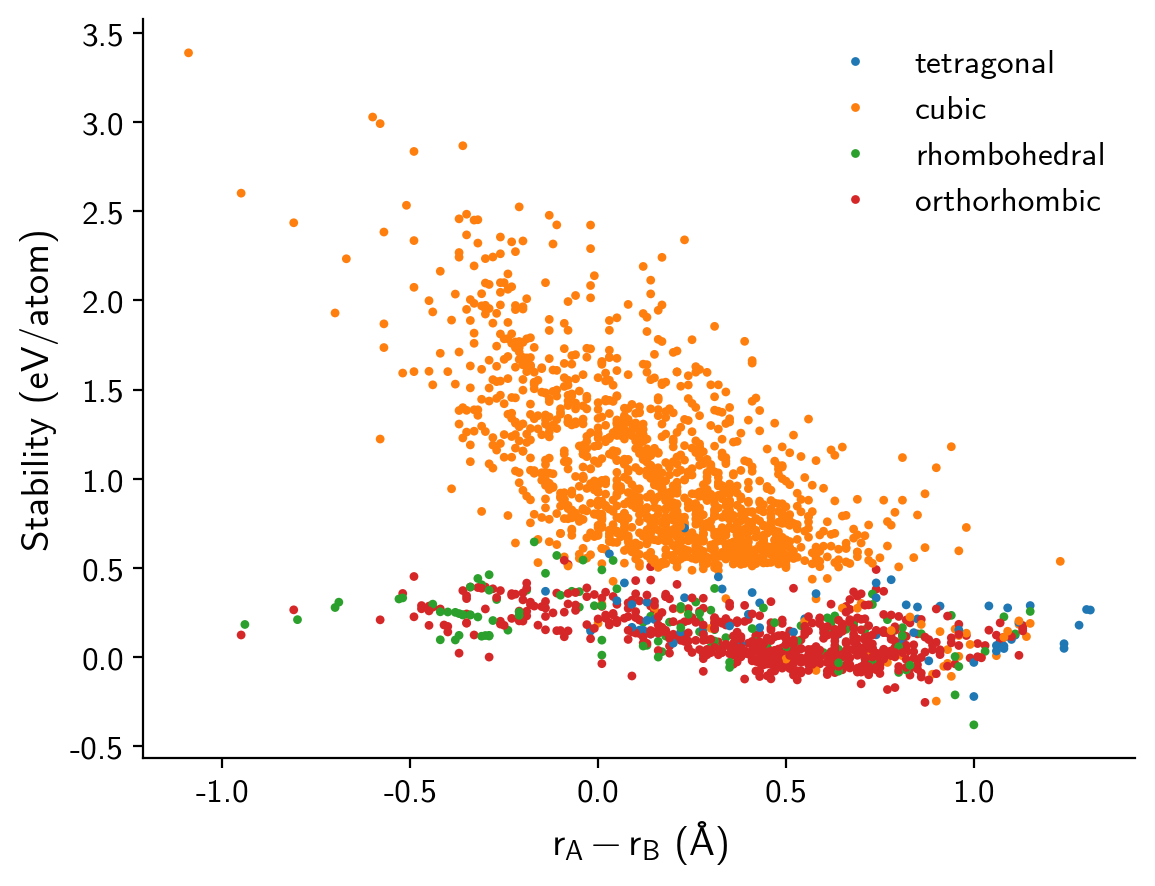

In [9]:
fig, ax = plt.subplots()

sns.scatterplot(
    data=subdf,
    x="dR",
    y="stability",
    hue="lattice",
    linewidth=0,
    ax=ax,
    s=10,
)
ax.legend(frameon=False)

ax.set_xlabel("$r_A - r_B$ (Å)")
ax.set_ylabel("Stability (eV/atom)")

plt.show()

It looks like that there is some relationship there.
Let us explore these a bit further.
Now let's investigate if there are significant differences of stability depending on the difference of oxidation states between the sites A and B:

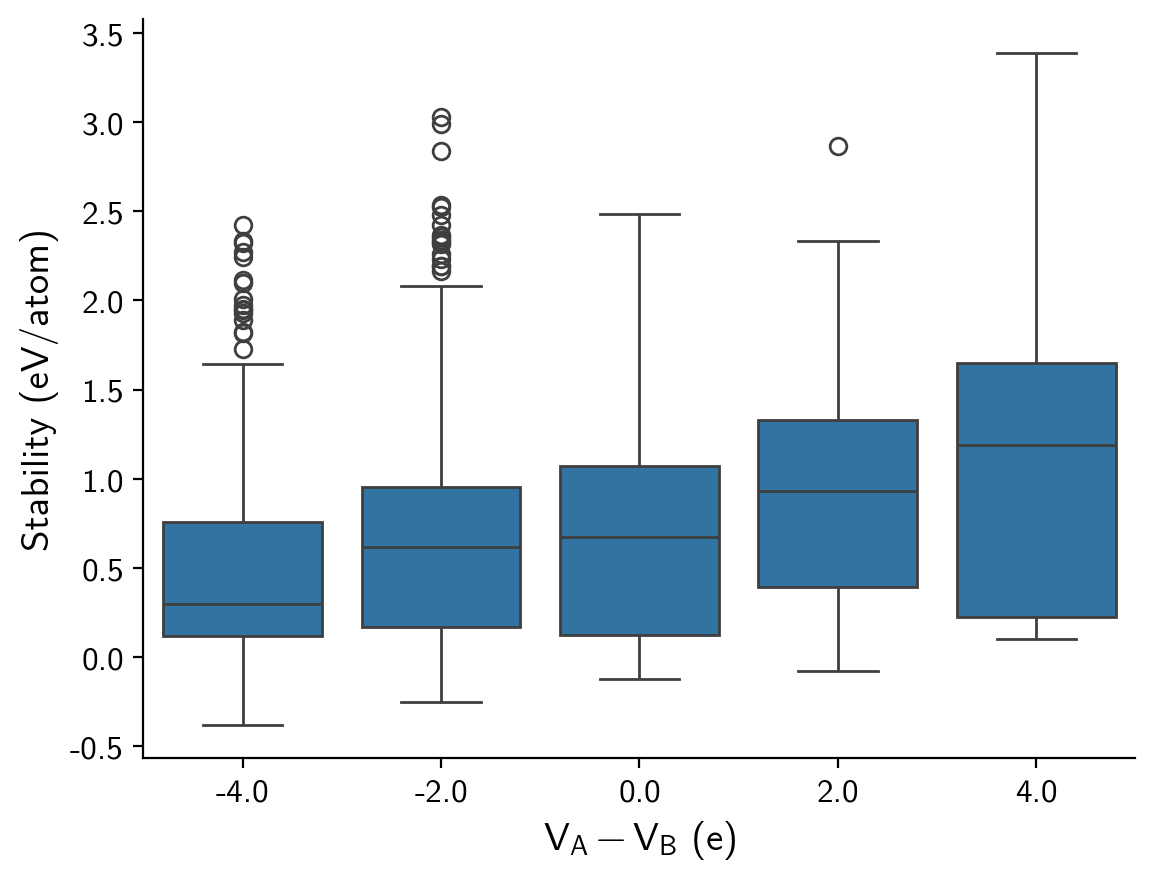

In [10]:
fig, ax = plt.subplots()

sns.boxplot(
    data=subdf,
    y="stability",
    x="dV",
)

ax.set_xlabel("$V_A - V_B$ (e)")
ax.set_ylabel("Stability (eV/atom)")

plt.show()

Again, the plot above shows that the perovskite is often more stable if the B site is more oxidized compared to the other way around.

What if we tried to see if there are relationships between the difference of electronegativity of A and B, the differences of radii, and the stability?

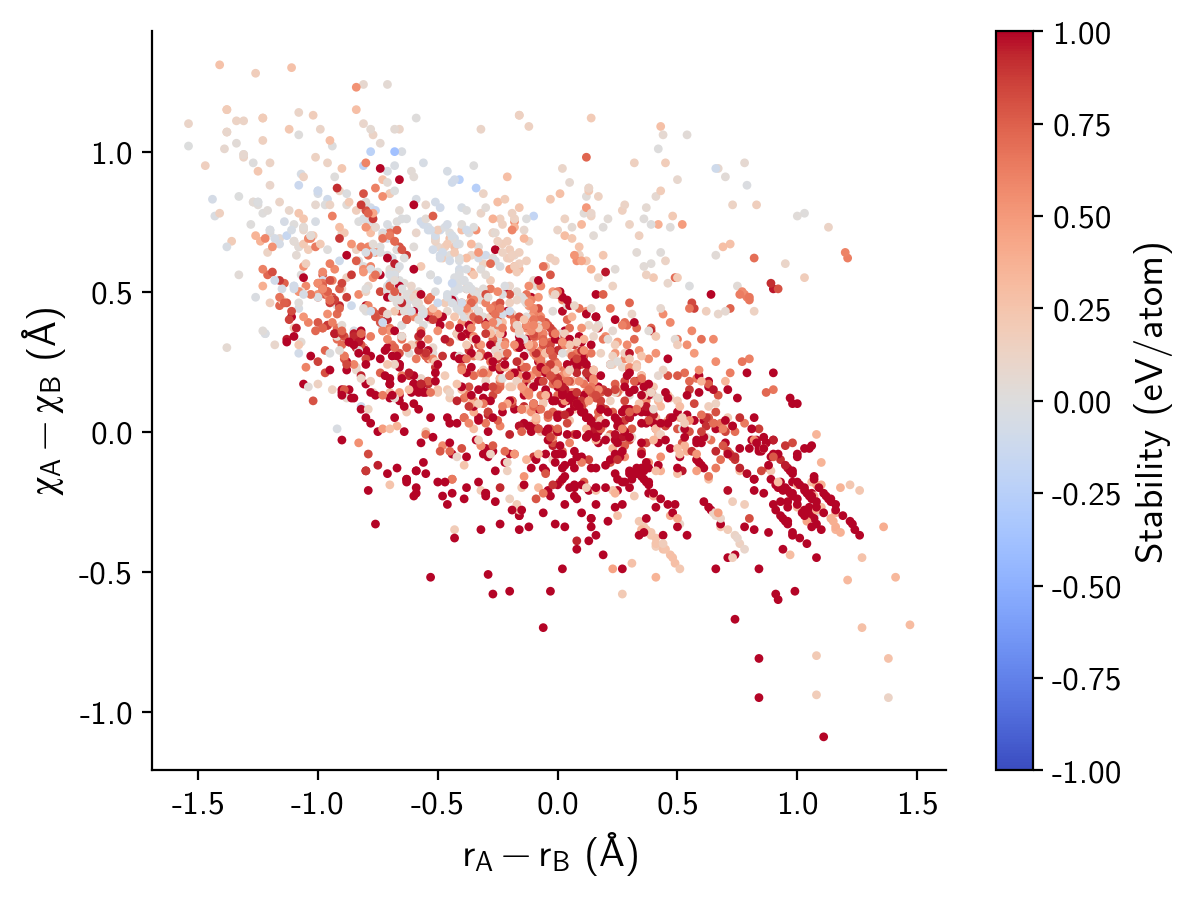

In [11]:
fig, ax = plt.subplots()

norm = plt.Normalize(-1, 1)

sc = ax.scatter(
    subdf["dEneg"],
    subdf["dR"],
    c=subdf["stability"],
    norm=norm,
    cmap="coolwarm",
    s=10,
    linewidth=0,
)

cbar = fig.colorbar(sc)
cbar.set_label("Stability (eV/atom)")

ax.set_xlabel("$r_A - r_B$ (Å)")
ax.set_ylabel("$\chi_A - \chi_B$ (Å)")

plt.show()

This plot already provides some insights:

1. Smaller A cations are preferred when compared to B cations
2. More electronegative A cations are preferred when compared to B cations

This derives naturally from the dataset, where the stability has been computed as the amount of energy to decompose towards other phases.

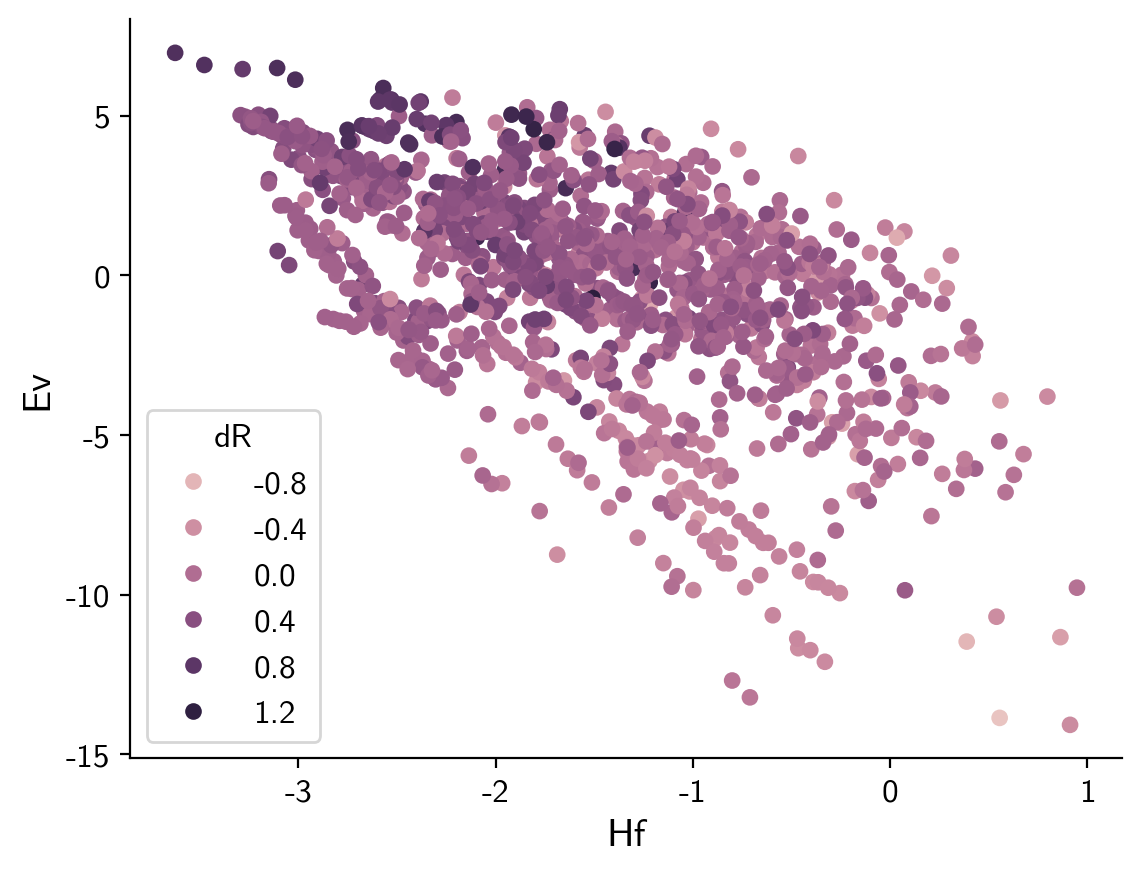

In [12]:
fig, ax = plt.subplots()

grp = subdf.loc[subdf["lattice"] == "cubic"]

sns.scatterplot(
    data=grp,
    x="Hf",
    y="Ev",
    hue="dR",
    linewidth=0,
)

plt.show()

Is there a preferred element to put in the A site?

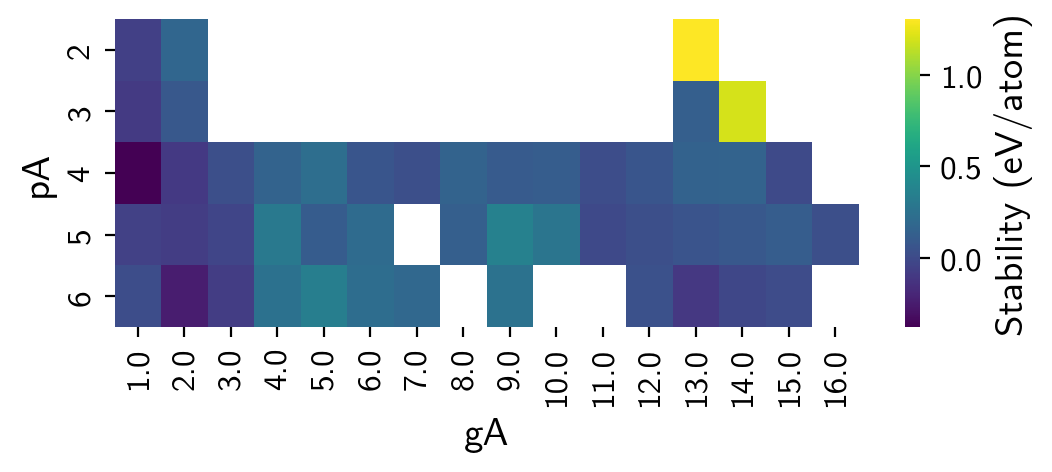

In [13]:
fig, ax = plt.subplots(figsize=(6, 2))

data = subdf.groupby(["pA", "gA"])["stability"].min().unstack()

ax = sns.heatmap(data, cmap="viridis", ax=ax, cbar_kws={"label": "Stability (eV/atom)"})

plt.show()

## The Goldschmidt tolerance factor

One of the well-known indicators of perovskite stability is called the [Goldschmidt tolerance factor](https://en.wikipedia.org/wiki/Goldschmidt_tolerance_factor).
For a perovskite of formula $ABO_3$, its formula is the following:

$$
t = \frac{1}{\sqrt{2}} \frac{r_A + r_O}{r_B + r_O},
$$

where $r_X$ is the ionic radius of element $X$. Let's use this tolerance factor to analyze our data assuming that $r_O = 1.26$ Å.

In [14]:
def tolerance_factor(rA, rB):
    rO = 1.26  # Å
    return (rA + rO) / (np.sqrt(2) * (rB + rO))

df["Goldschmidt"] = tolerance_factor(df["rA"].values, df["rB"].values)

We can compare the distribution of perovskites as a function of their tolerance factor.
Specifically, we can split them in two groups: known perovskites (green), and not known perovskites (red), as assigned by the authors of the data:

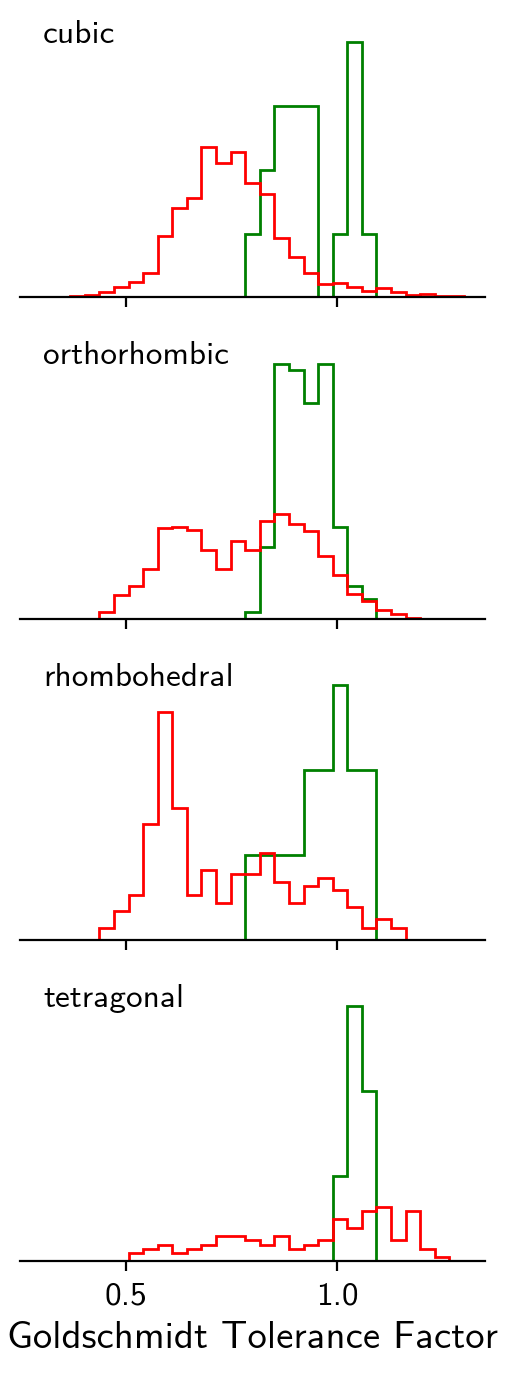

In [15]:
fig, axs = plt.subplots(4, 1, figsize=(3, 8), sharex=True)

bins = np.linspace(0.3, 1.3, 30)

for ax, (name, grp) in zip(axs, df.groupby("lattice")):
    pos = grp.loc[grp["known"]]
    neg = grp.loc[~grp["known"]]
    
    ax.hist(pos["Goldschmidt"], bins=bins, label=name, histtype="step", density=True, color="g")
    ax.hist(neg["Goldschmidt"], bins=bins, label=name, histtype="step", density=True, color="r")
    
    ax.annotate(name, (0.05, 0.95), xycoords="axes fraction")
    ax.set_yticks([])
    ax.spines["left"].set_visible(False)


axs[-1].set_xlabel("Goldschmidt Tolerance Factor")

plt.show()

In the results above, we see how known perovskites tend to be concentrated around a tolerance factor of 1.0.

## Other structure-property relationships

For many applications, it is useful to look for perovskites that satisfy other properties beyond its structural stability.
For instance, perovskites that are used for photocatalytic water splitting need to have a certain range of oxygen vacancy formation energies to maximize activity and do not degrade the perovskite.
Let us visualize how the enthalpy of formation of the perovskite ($\Delta H_f$) relates to the oxygen vacancy formation energy ($E_v$):

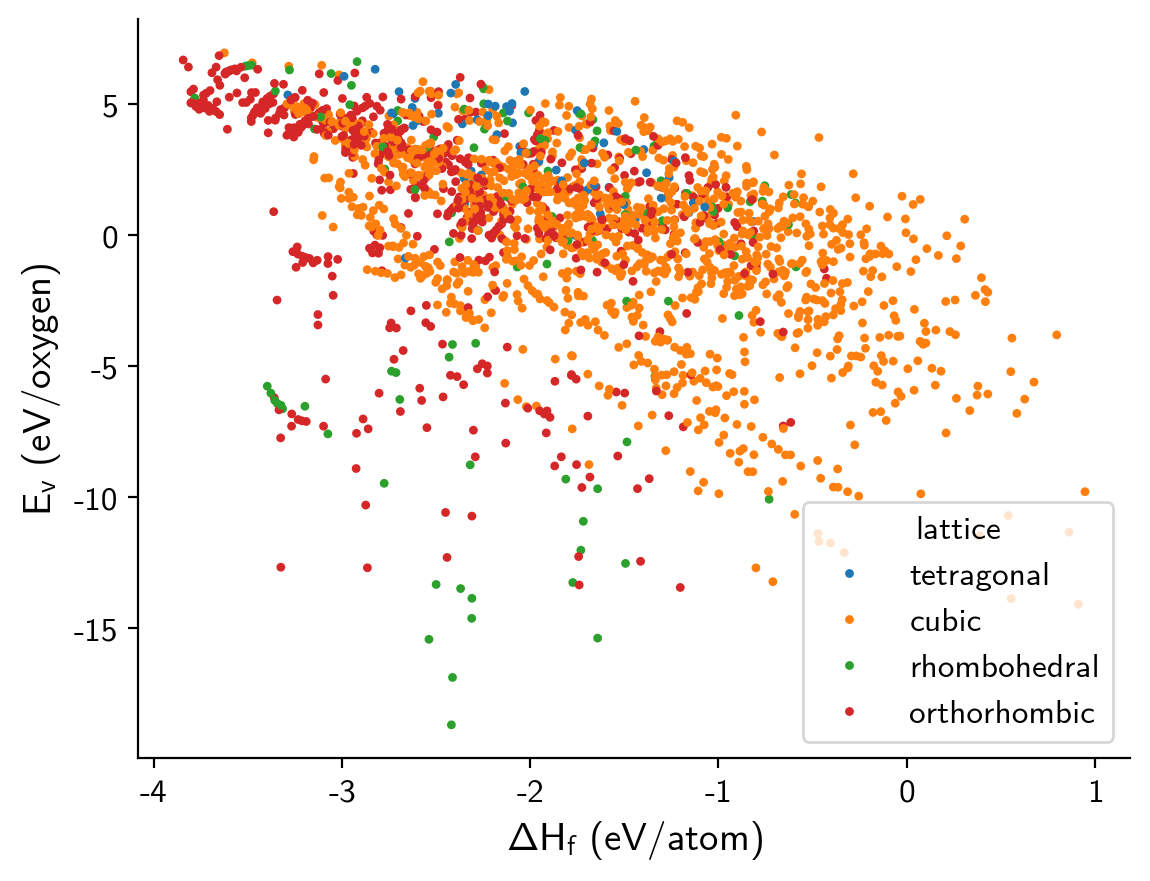

In [16]:
fig, ax = plt.subplots()

sns.scatterplot(
    data=subdf,
    x="Hf",
    y="Ev",
    hue="lattice",
    linewidth=0,
    s=10,
    ax=ax
)

ax.set_xlabel("$\Delta H_f$ (eV/atom)")
ax.set_ylabel("$E_v$ (eV/oxygen)")

plt.show()

Unsurprisingly, the most stable perovskites tend to have higher oxygen vacancy formation energies.

Let us say that we are specifically in the range of $2.5 < E_v < 5.0$ eV/O atom for water splitting applications.
How would you design a perovskite for these purposes?

You can simply use the dataset to filter out the most promising candidates:

In [17]:
final = (subdf.loc[
    (subdf["Ev"] > 2.5)
    & (subdf["Ev"] < 5.0)
    # & (subdf["dEneg"] < 0)
    & (subdf["stability"] < 0.025)
    # & (subdf["lattice"] == "orthorhombic")
]).dropna()

In [18]:
final.sort_values("stability").iloc[:50]

,formula,A,B,known,vA,vB,rA,rB,lattice,Hf,...,Ev,dR,dV,EnegA,EnegB,dEneg,gA,gB,pA,pB
2184,LaVO3,La,V,True,3.0,3.0,1.36,0.64,orthorhombic,-3.248,...,4.609,0.72,0.0,1.10,1.63,-0.53,3.0,5.0,6,4
2130,LaCrO3,La,Cr,True,3.0,3.0,1.36,0.62,orthorhombic,-3.168,...,4.845,0.74,0.0,1.10,1.66,-0.56,3.0,6.0,6,4
2136,LaFeO3,La,Fe,True,3.0,3.0,1.36,0.65,orthorhombic,-2.755,...,4.037,0.71,0.0,1.10,1.83,-0.73,3.0,8.0,6,4
5050,YCrO3,Y,Cr,True,3.0,3.0,1.08,0.62,orthorhombic,-3.178,...,4.248,0.46,0.0,1.22,1.66,-0.44,3.0,6.0,5,4
5104,YVO3,Y,V,True,3.0,3.0,1.08,0.64,orthorhombic,-3.250,...,3.984,0.44,0.0,1.22,1.63,-0.41,3.0,5.0,5,4
5056,YFeO3,Y,Fe,True,3.0,3.0,1.08,0.65,orthorhombic,-2.758,...,3.19,0.43,0.0,1.22,1.83,-0.61,3.0,8.0,5,4
2137,LaGaO3,La,Ga,True,3.0,3.0,1.36,0.62,orthorhombic,-2.935,...,4.934,0.74,0.0,1.10,1.81,-0.71,3.0,13.0,6,4
2129,LaCoO3,La,Co,True,3.0,3.0,1.36,0.61,orthorhombic,-2.505,...,2.964,0.75,0.0,1.10,1.88,-0.78,3.0,9.0,6,4
724,CaVO3,Ca,V,True,2.0,4.0,1.34,0.58,orthorhombic,-2.901,...,3.563,0.76,-2.0,1.00,1.63,-0.63,2.0,5.0,4,4
4212,SrRuO3,Sr,Ru,True,2.0,4.0,1.44,0.62,orthorhombic,-2.024,...,3.136,0.82,-2.0,0.95,2.20,-1.25,2.0,8.0,5,5


This shows that by adding some filters to the materials given the computational data, one can select interesting perovskites for future testing.
These methods can be quite useful in data-driven materials design, especially as one considers the behavior of materials in different regimes.

## Extra reading

More on the Goldschmidt tolerance factor and improved methods: https://www.science.org/doi/full/10.1126/sciadv.aav0693

Example of papers discussing some interesting perovskites:

- BaSnO$_3$: https://doi.org/10.1002/adma.201903316
- BiVO$_3$: https://www.sciencedirect.com/science/article/abs/pii/S027288421201396X